In [328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [329]:
# Load the datasets

earthquake_data = pd.read_csv('clean_major_earthquakes.csv') # magnitude >= 6, 2008-2023
stock_data = pd.read_csv('stock_data.csv')
japan_stock_data = pd.read_csv('clean_225_stocks_data.csv')

print(earthquake_data.head())
print('---')
print(stock_data.head())
print('---')
print(japan_stock_data.head())

   tsunami  significance   data_type  magnitude              state  longitude  \
0        0           613  earthquake        6.3   Papua New Guinea    146.884   
1        0           557  earthquake        6.0          Indonesia    101.032   
2        0           671  earthquake        6.6             Canada   -130.746   
3        0           630  earthquake        6.4             Canada   -130.542   
4        0           920  earthquake        6.2             Greece     22.693   

   latitude  depth        date                   time  
0    -5.878   34.0  2008-01-01  18:54:59.010000+00:00  
1    -2.782   35.0  2008-01-04  07:29:18.300000+00:00  
2    51.254   15.0  2008-01-05  11:01:06.110000+00:00  
3    51.163   10.0  2008-01-05  11:44:48.170000+00:00  
4    37.216   75.0  2008-01-06  05:14:20.180000+00:00  
---
   Ticker        Date          Open         Close        Volume
0    ^NYA  2008-08-01   8438.709961   8379.150391  4.684870e+09
1   ^IXIC  2008-08-01   2326.830078   2310.95

In [330]:
# Convert the 'date', 'Date' column to datetime format and extract the date part.
earthquake_data['date'] = pd.to_datetime(earthquake_data['date']).dt.date
stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.date
japan_stock_data['Date'] = pd.to_datetime(japan_stock_data['Date']).dt.date

In [345]:
# Filter Earthquake Data for Japan
# Define Japan's approximate latitude and longitude range
japan_lat_range = (24, 46)
japan_lon_range = (122, 146)

# Filter earthquakes within Japan's range
japan_earthquakes = earthquake_data[
    (earthquake_data['latitude'].between(*japan_lat_range)) &
    (earthquake_data['longitude'].between(*japan_lon_range))
]

print(japan_earthquakes)

      tsunami  significance   data_type  magnitude          state  longitude  \
32          0           591  earthquake        6.2   Japan region   142.4380   
39          0           554  earthquake        6.0   Japan region   142.5990   
69          0           608  earthquake        6.2          Japan   141.5450   
70          0           573  earthquake        6.1          Japan   141.7560   
71          0           910  earthquake        6.9          Japan   141.5260   
...       ...           ...         ...        ...            ...        ...   
2156        0           567  earthquake        6.0   Japan region   145.0212   
2169        0           560  earthquake        6.0   Japan region   142.8148   
2182        0           692  earthquake        6.2          Japan   137.2994   
2191        0           679  earthquake        6.1          Japan   140.5281   
2194        0           617  earthquake        6.2          Japan   141.9005   

      latitude  depth        date      

In [347]:
# Count the number of earthquakes
num_earthquakes = japan_earthquakes[japan_earthquakes['data_type'] == 'earthquake'].shape[0]

# Print the result
print(f"Number of earthquakes: {num_earthquakes}")

Number of earthquakes: 207


In [332]:
# Merge earthquake data with Japan stock data
merged_data = pd.merge(japan_stock_data, japan_earthquakes, left_on='Date', right_on='date', how='left')

print(merged_data.head())

   Ticker  Company_name Industry        Date        Open       Close   Volume  \
0  1332.T  NISSUI CORP.  Fishery  2007-01-04  496.986243  500.496033   855800   
1  1332.T  NISSUI CORP.  Fishery  2007-01-05  510.323594  520.852966  4653800   
2  1332.T  NISSUI CORP.  Fishery  2007-01-09  513.833276  510.323486  2779700   
3  1332.T  NISSUI CORP.  Fishery  2007-01-10  505.409781  492.774536  3638400   
4  1332.T  NISSUI CORP.  Fishery  2007-01-11  497.688220  490.668640  2608400   

   tsunami  significance data_type  magnitude state  longitude  latitude  \
0      NaN           NaN       NaN        NaN   NaN        NaN       NaN   
1      NaN           NaN       NaN        NaN   NaN        NaN       NaN   
2      NaN           NaN       NaN        NaN   NaN        NaN       NaN   
3      NaN           NaN       NaN        NaN   NaN        NaN       NaN   
4      NaN           NaN       NaN        NaN   NaN        NaN       NaN   

   depth date time  
0    NaN  NaN  NaN  
1    NaN  NaN 

In [333]:
# Analyze the Impact of Earthquakes
## Impact on Stock Prices
## We can analyze the impact of earthquakes on stock prices by comparing the Open and Close prices before and after an earthquake.

# Create a new column to indicate if there was an earthquake on that day
merged_data['earthquake'] = merged_data['magnitude'].notna()

# Group by Ticker and earthquake to see the average change in stock prices
impact_on_prices = merged_data.groupby(['Ticker', 'earthquake']).agg({
    'Open': 'mean',
    'Close': 'mean'
}).reset_index()

# Calculate the percentage change in stock prices
impact_on_prices['price_change'] = (impact_on_prices['Close'] - impact_on_prices['Open']) / impact_on_prices['Open'] * 100

In [334]:
# Impact on Trading Volume
## Similarly, we can analyze the impact on trading volume.

# Group by Ticker and earthquake to see the average change in trading volume
impact_on_volume = merged_data.groupby(['Ticker', 'earthquake']).agg({
    'Volume': 'mean'
}).reset_index()

# Calculate the percentage change in trading volume
impact_on_volume['volume_change'] = (impact_on_volume['Volume'] - impact_on_volume['Volume'].shift(1)) / impact_on_volume['Volume'].shift(1) * 100

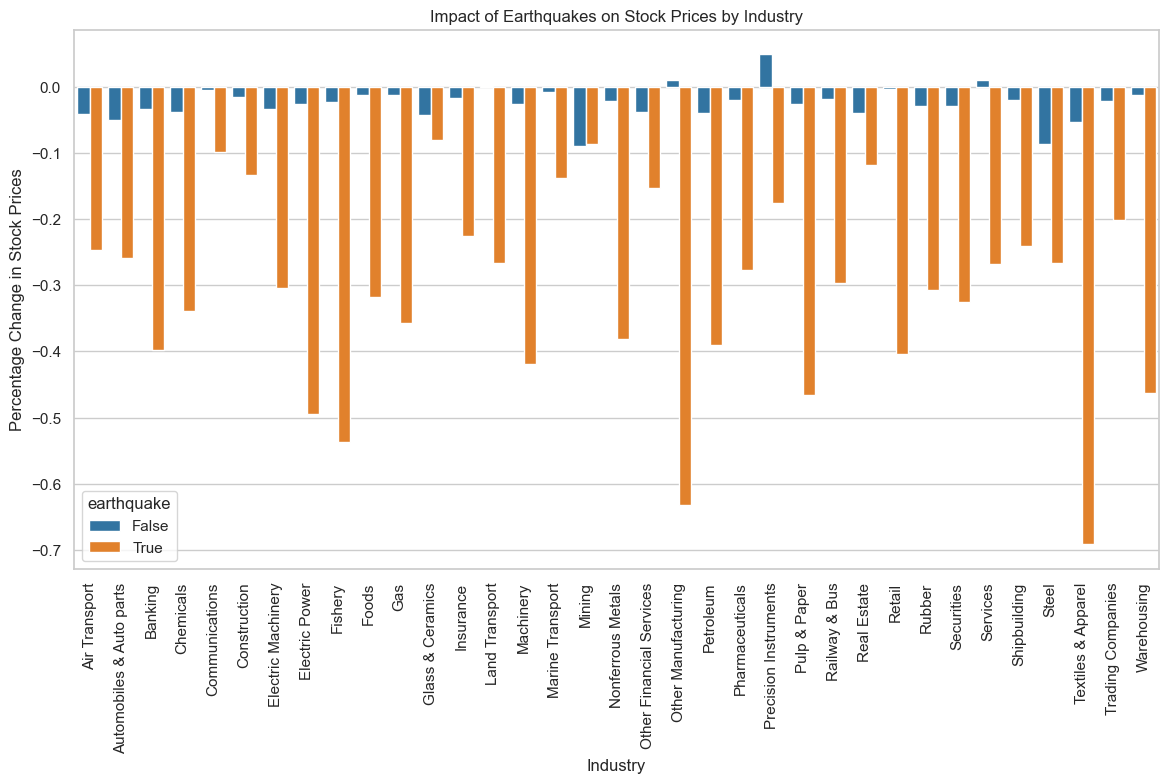

In [335]:
# Industry-wise Analysis
## To analyze the impact on different industries, we can group the data by Industry and perform similar analyses.
# Group by Industry and earthquake to see the average change in stock prices
industry_impact_on_prices = merged_data.groupby(['Industry', 'earthquake']).agg({
    'Open': 'mean',
    'Close': 'mean'
}).reset_index()

# Calculate the percentage change in stock prices
industry_impact_on_prices['price_change'] = (industry_impact_on_prices['Close'] - industry_impact_on_prices['Open']) / industry_impact_on_prices['Open'] * 100

# Visualize the impact on stock prices by industry
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='price_change', hue='earthquake', data=industry_impact_on_prices)
plt.title('Impact of Earthquakes on Stock Prices by Industry')
plt.xlabel('Industry')
plt.ylabel('Percentage Change in Stock Prices')
plt.xticks(rotation=90)
plt.show()

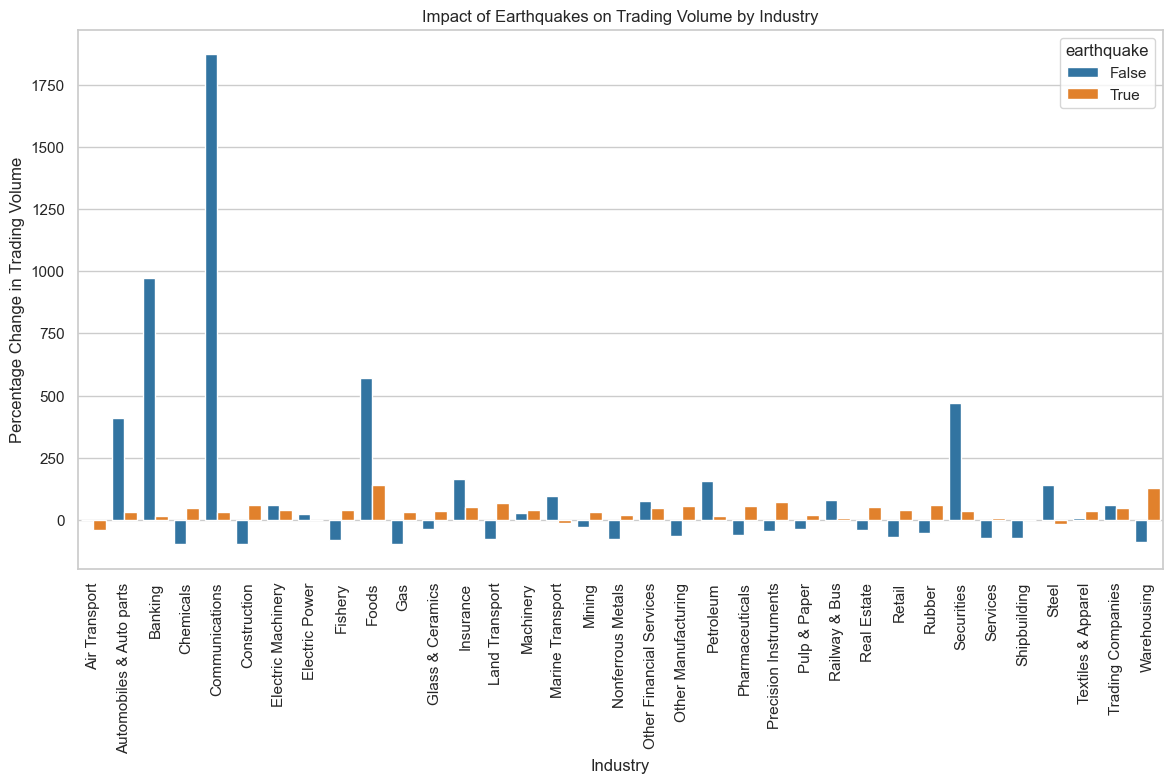

In [336]:
# Industry-wise Analysis
## To analyze the impact on trading volume across different industries, group the data by Industry and earthquake.
# Group by Industry and earthquake to see the average change in trading volume
industry_impact_on_volume = merged_data.groupby(['Industry', 'earthquake']).agg({
    'Volume': 'mean'  # Calculate the mean trading volume
}).reset_index()

# Calculate the percentage change in trading volume
industry_impact_on_volume['volume_change'] = (industry_impact_on_volume['Volume'] - industry_impact_on_volume['Volume'].shift(1)) / industry_impact_on_volume['Volume'].shift(1) * 100

# Replace NaN values in the first row with 0 (since there's no previous value to compare)
industry_impact_on_volume['volume_change'] = industry_impact_on_volume['volume_change'].fillna(0)  # Fixed: Avoid inplace=True

# Visualize the impact on trading volume by industry
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='volume_change', hue='earthquake', data=industry_impact_on_volume, errorbar=None)  # Use errorbar=None to disable confidence intervals
plt.title('Impact of Earthquakes on Trading Volume by Industry')
plt.xlabel('Industry')
plt.ylabel('Percentage Change in Trading Volume')
plt.xticks(rotation=90)
plt.show()

## Impact of Earthquake on Stock Prices by Industry

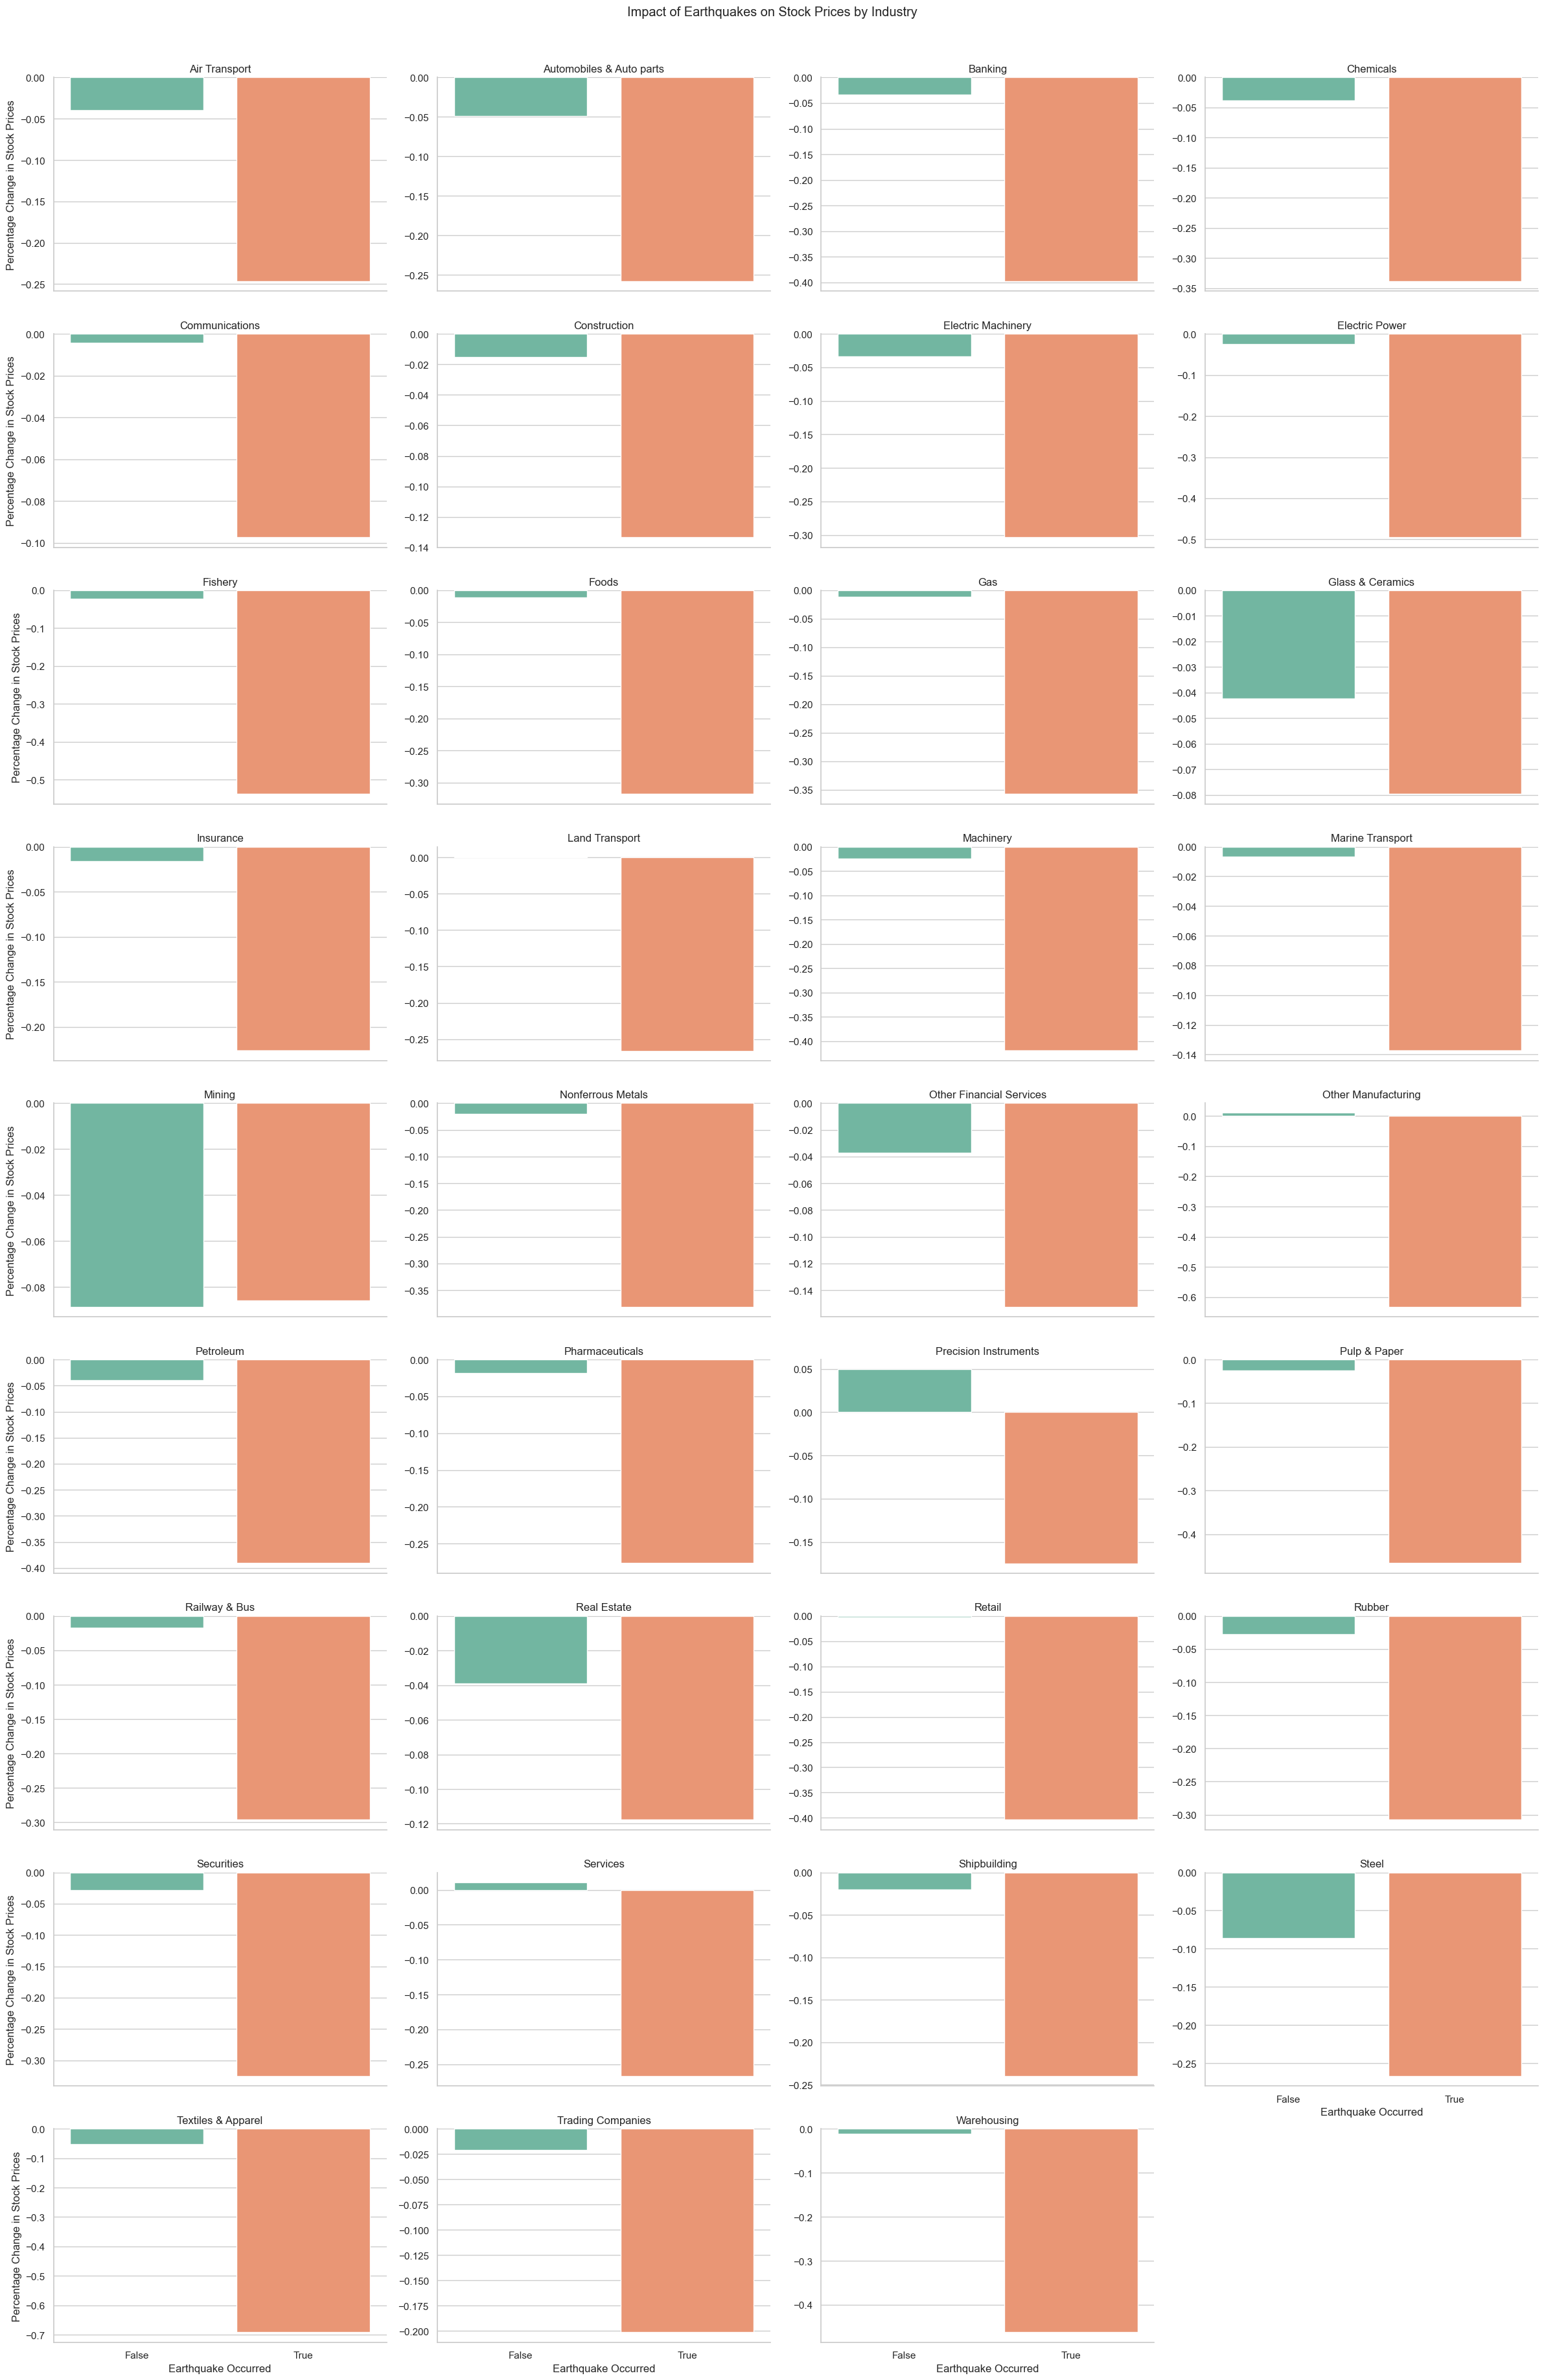

In [337]:
# Group the data by Industry and earthquake, and calculate the average percentage change in stock prices
industry_impact_on_prices = merged_data.groupby(['Industry', 'earthquake']).agg({
    'Open': 'mean',
    'Close': 'mean'
}).reset_index()

# Calculate the percentage change in stock prices
industry_impact_on_prices['price_change'] = (industry_impact_on_prices['Close'] - industry_impact_on_prices['Open']) / industry_impact_on_prices['Open'] * 100

# Create a faceted bar plot for each industry
g = sns.FacetGrid(industry_impact_on_prices, col='Industry', col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map_dataframe(sns.barplot, x='earthquake', y='price_change', hue='earthquake', palette='Set2', dodge=False, legend=False)
g.set_axis_labels('Earthquake Occurred', 'Percentage Change in Stock Prices')
g.set_titles('{col_name}')
g.fig.suptitle('Impact of Earthquakes on Stock Prices by Industry', y=1.02)
plt.show()

## Impact of Earthquake on Trading Volume by Industry

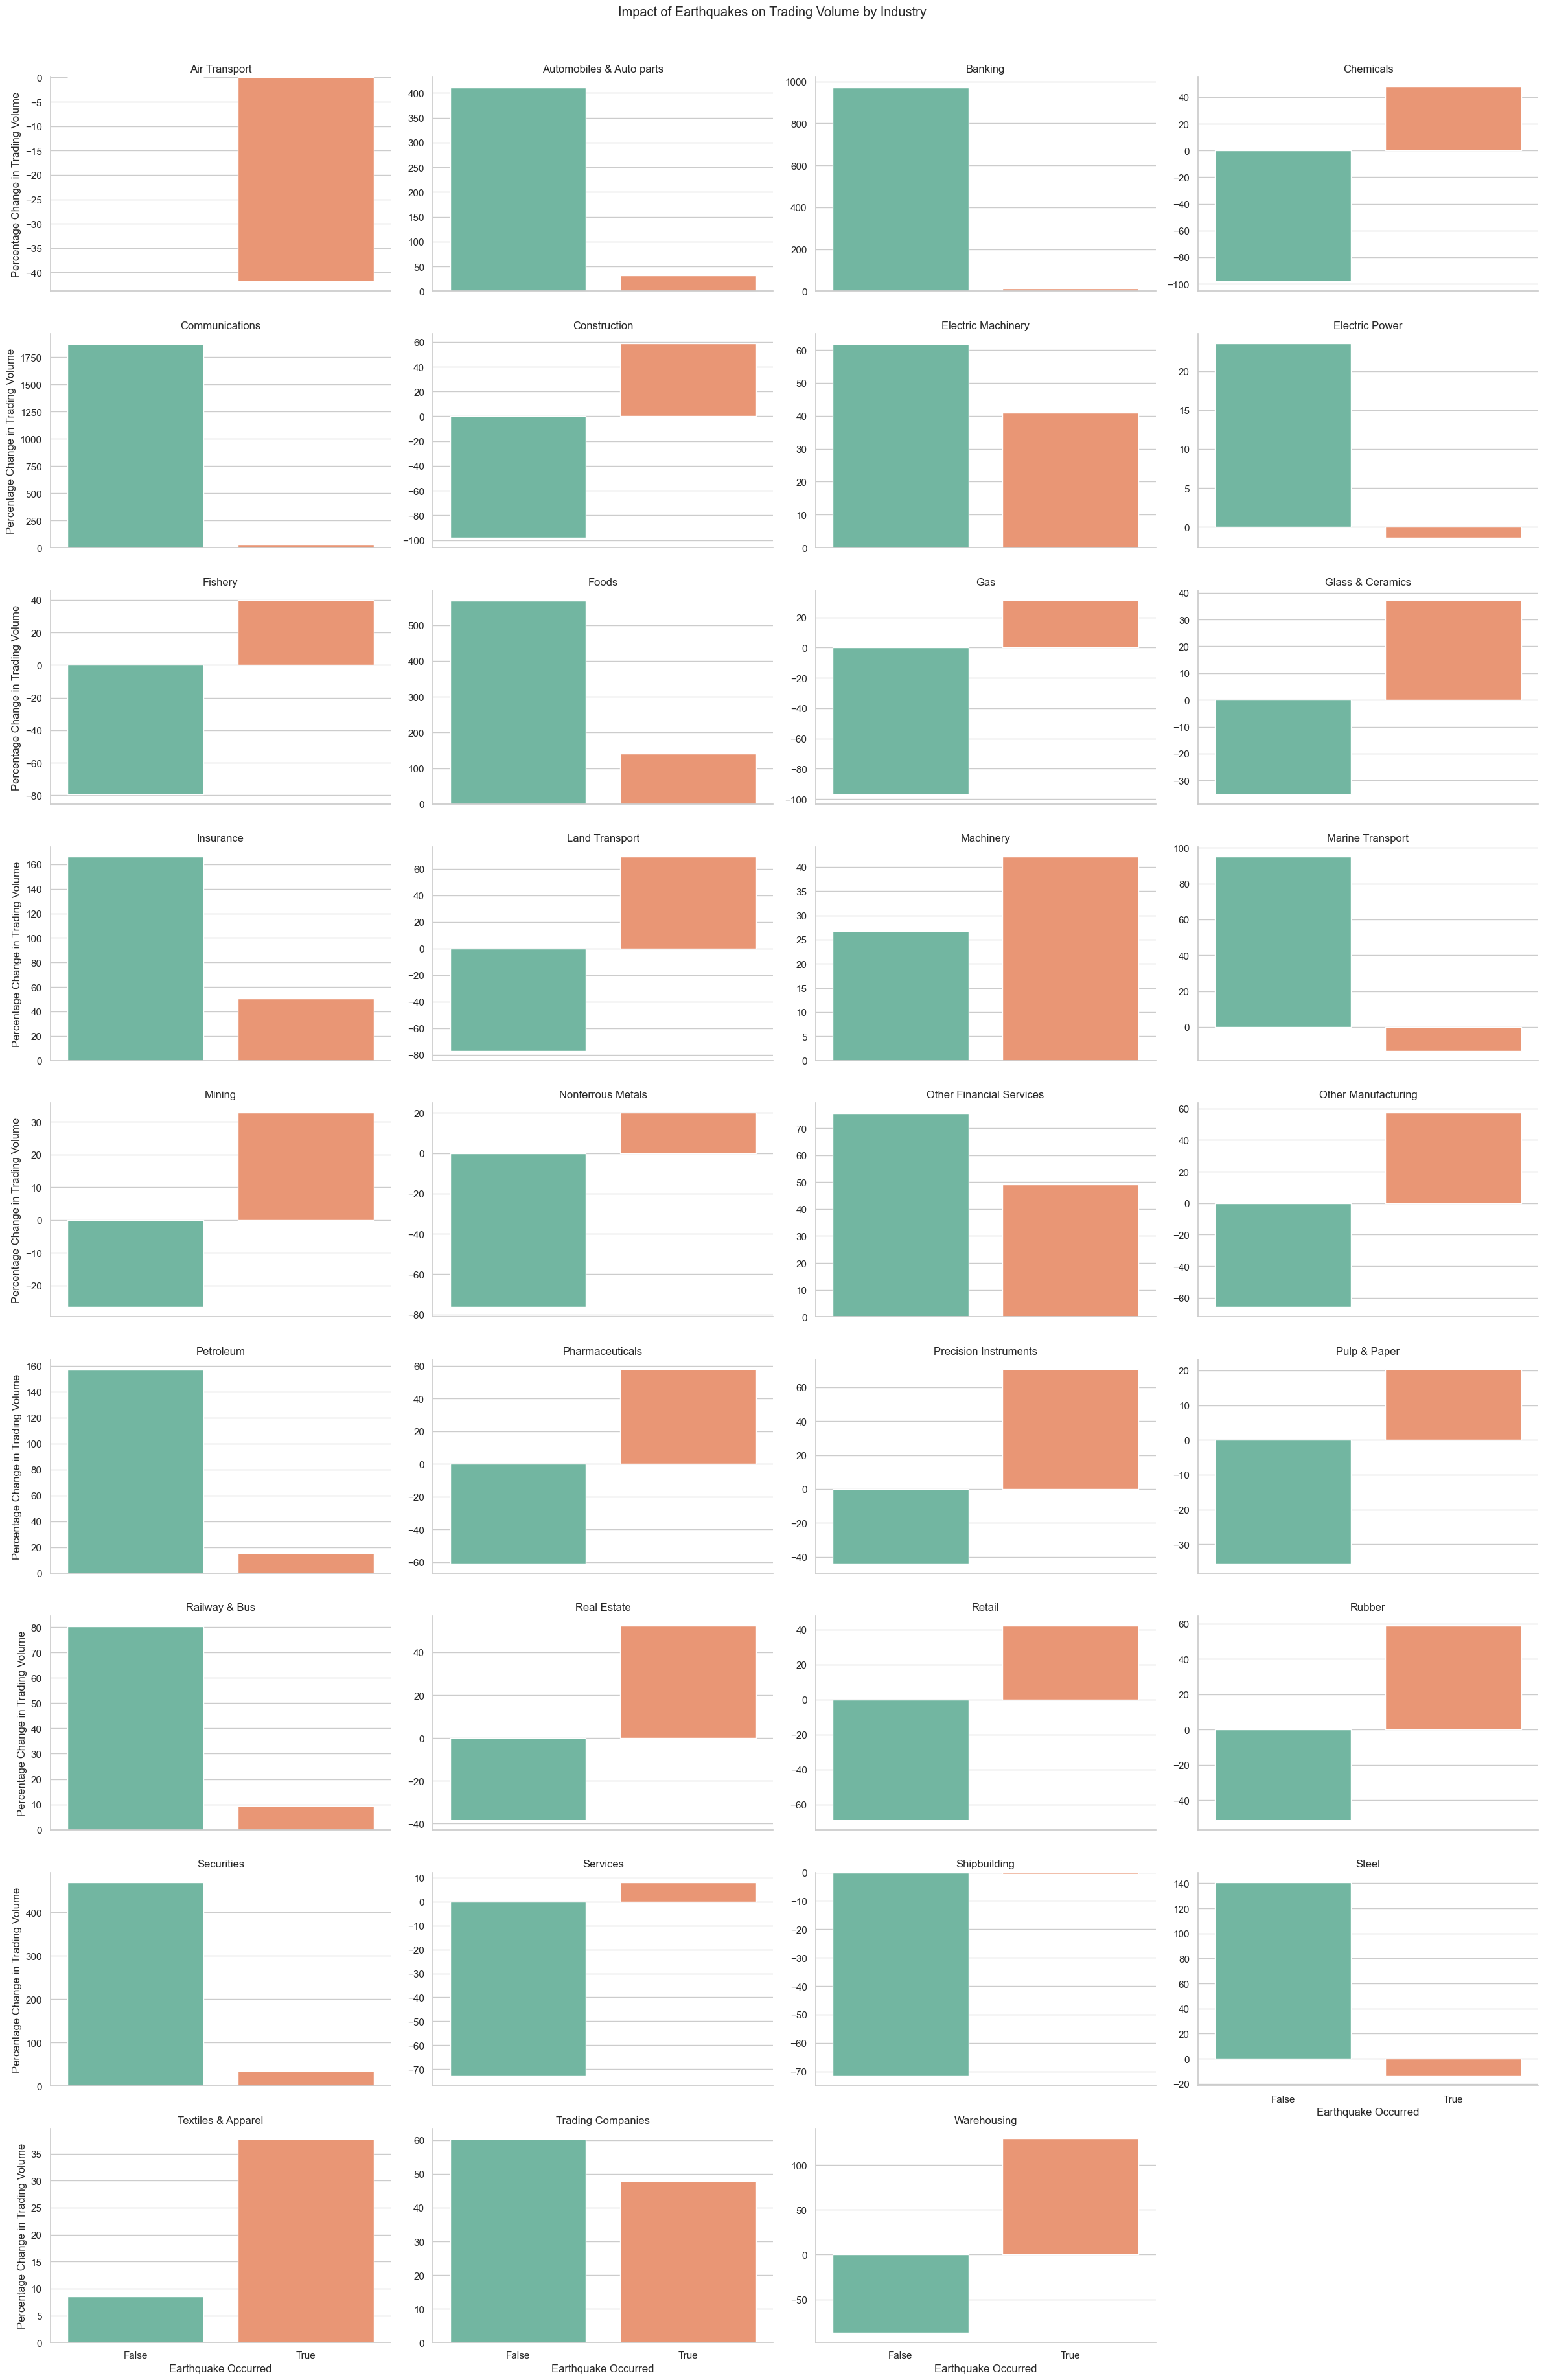

In [338]:
# Group the data by Industry and earthquake, and calculate the average trading volume
industry_impact_on_volume = merged_data.groupby(['Industry', 'earthquake']).agg({
    'Volume': 'mean'
}).reset_index()

# Calculate the percentage change in trading volume
industry_impact_on_volume['volume_change'] = (industry_impact_on_volume['Volume'] - industry_impact_on_volume['Volume'].shift(1)) / industry_impact_on_volume['Volume'].shift(1) * 100

# Replace NaN values in the first row with 0 (since there's no previous value to compare)
industry_impact_on_volume['volume_change'] = industry_impact_on_volume['volume_change'].fillna(0)  # Fixed: Avoid inplace=True

# Create a faceted bar plot for each industry
g = sns.FacetGrid(industry_impact_on_volume, col='Industry', col_wrap=4, height=4, aspect=1.5, sharey=False)
g.map_dataframe(sns.barplot, x='earthquake', y='volume_change', hue='earthquake', palette='Set2', dodge=False, legend=False)
g.set_axis_labels('Earthquake Occurred', 'Percentage Change in Trading Volume')
g.set_titles('{col_name}')
g.fig.suptitle('Impact of Earthquakes on Trading Volume by Industry', y=1.02)
plt.show()

## Impact of Earthquake on Stock Prices by Industry (show all Companies)

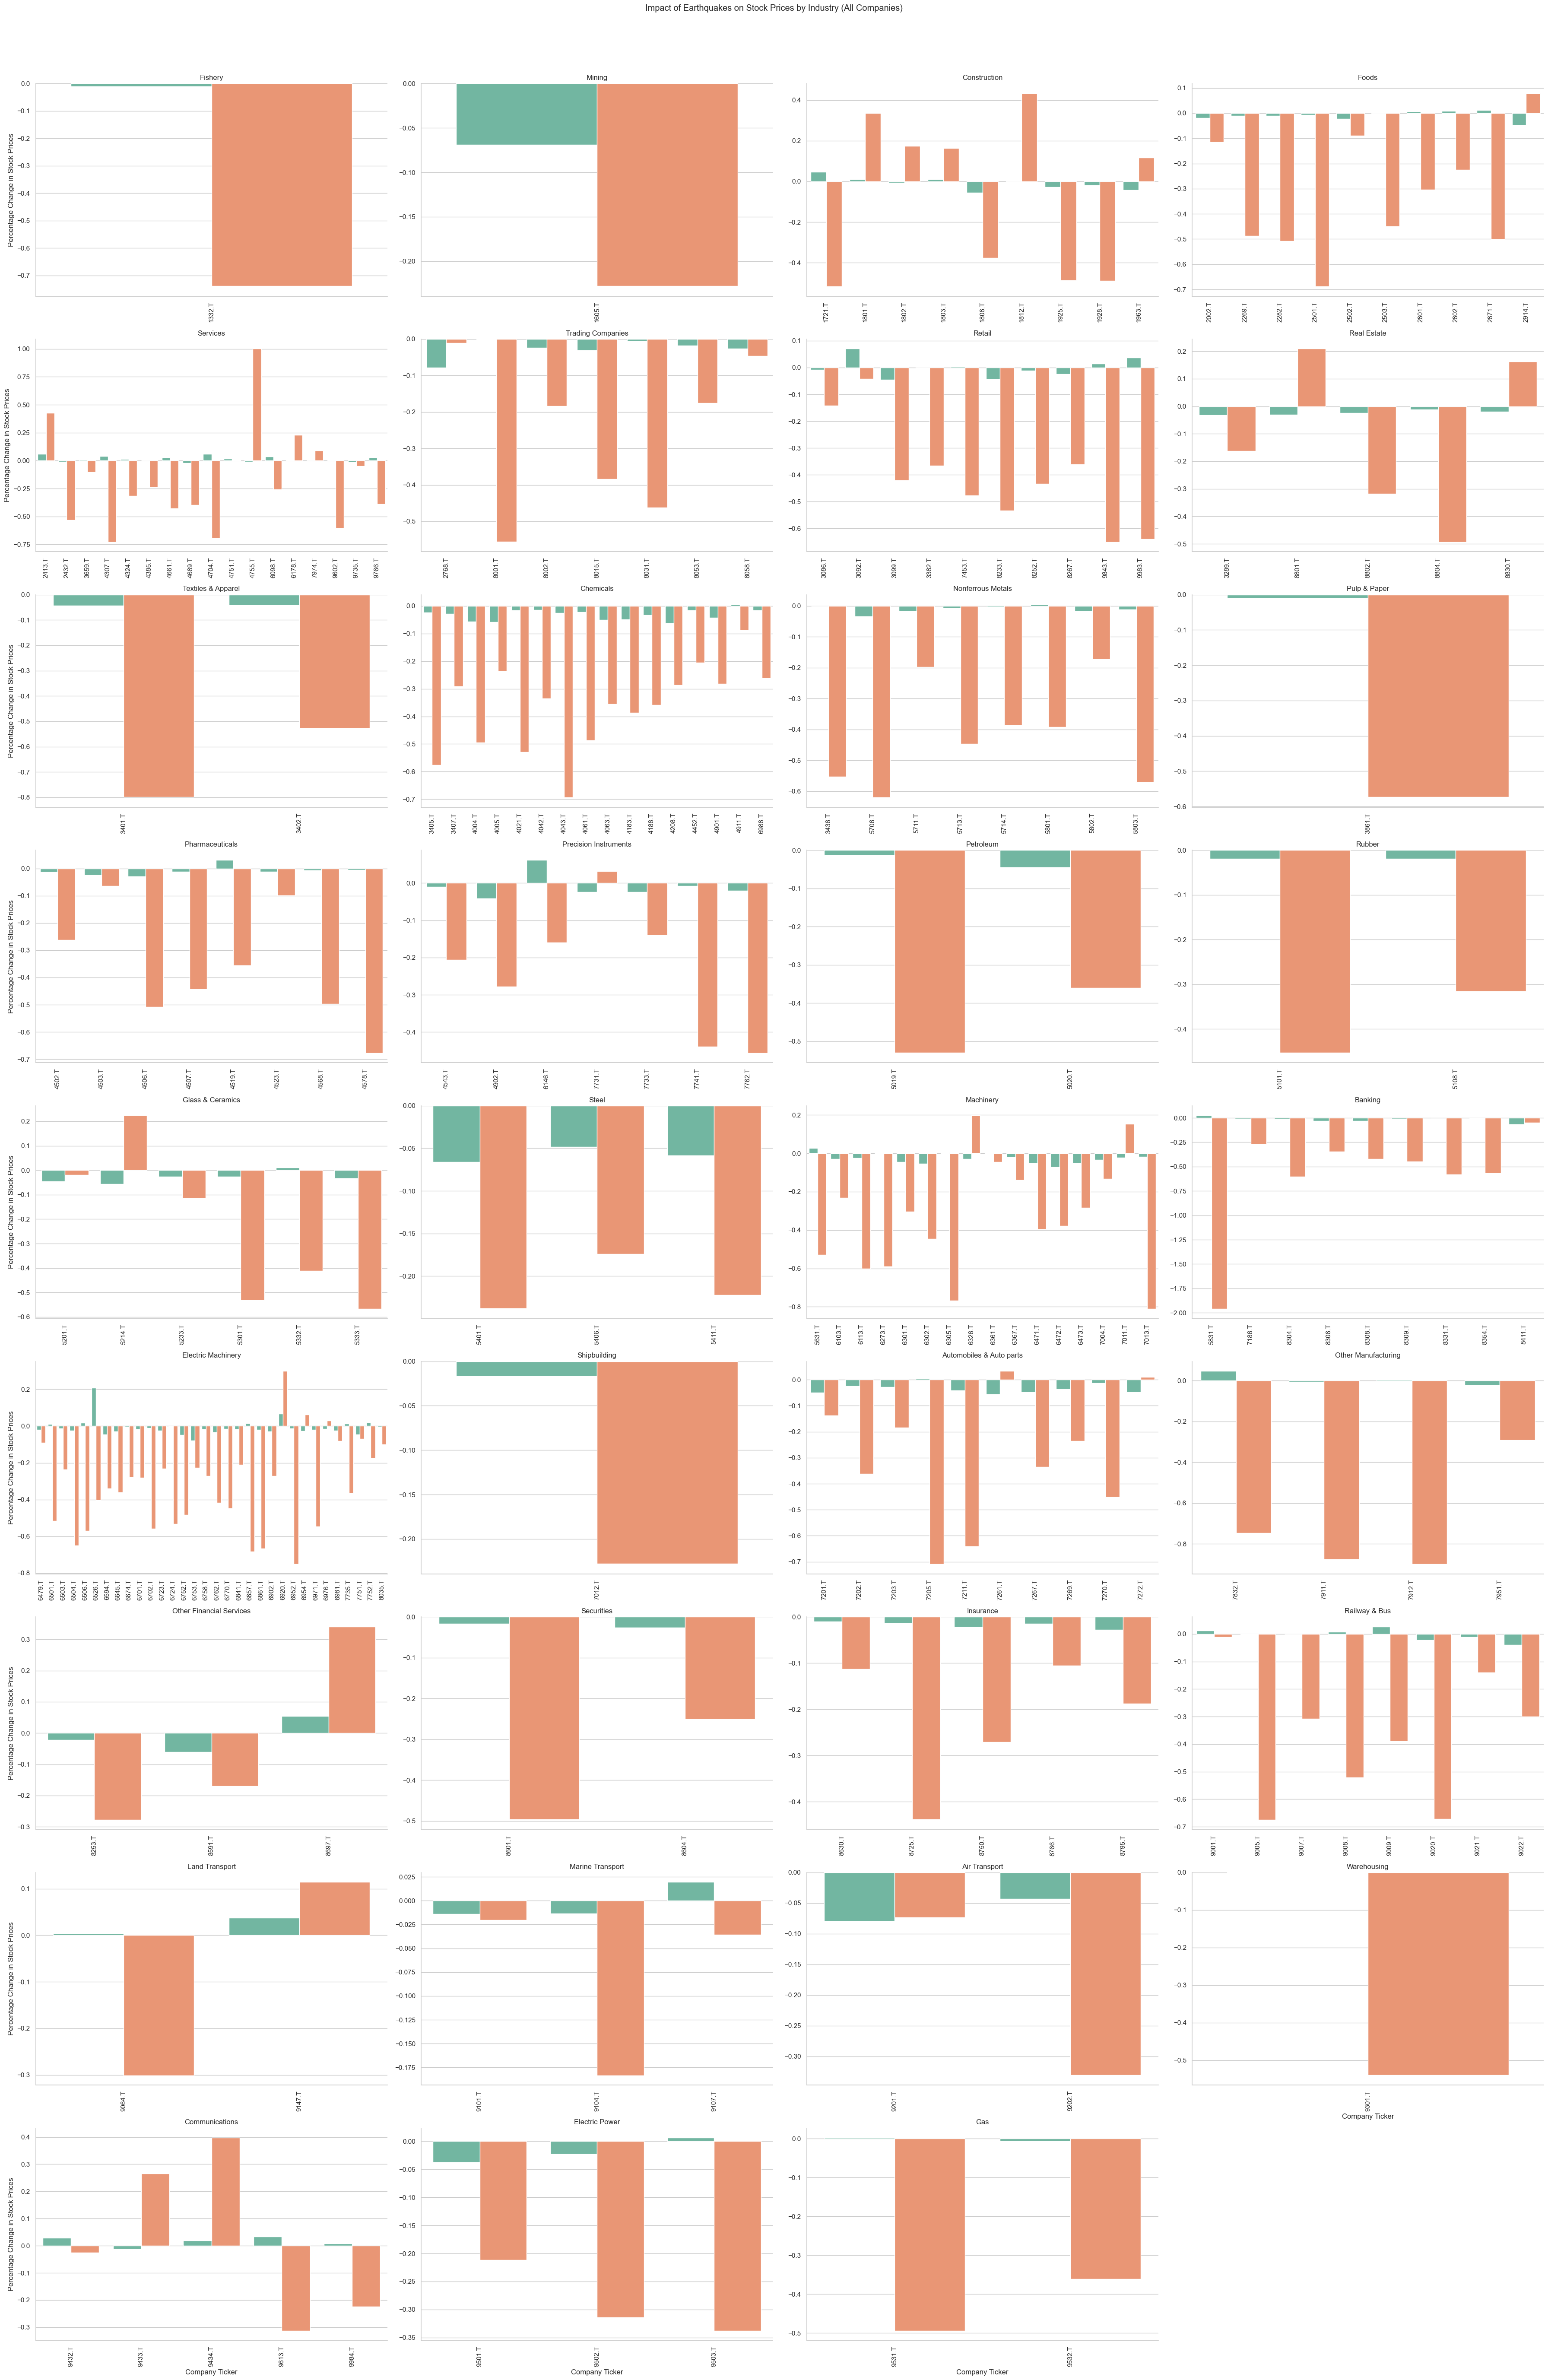

In [339]:
# Calculate the percentage change in stock prices for each company
merged_data['price_change'] = (merged_data['Close'] - merged_data['Open']) / merged_data['Open'] * 100

# Create a faceted bar plot for each industry, showing all companies
g = sns.FacetGrid(merged_data, col='Industry', col_wrap=4, height=6, aspect=1.5, sharey=False, sharex=False)
g.map_dataframe(sns.barplot, x='Ticker', y='price_change', hue='earthquake', palette='Set2', dodge=True, errorbar=None)  # Fixed: Use errorbar=None instead of ci=None
g.set_axis_labels('Company Ticker', 'Percentage Change in Stock Prices')
g.set_titles('{col_name}')
g.fig.suptitle('Impact of Earthquakes on Stock Prices by Industry (All Companies)', y=1.02)

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    ax.set_xticks(ax.get_xticks())  # Fix the number of ticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

## Impact of Earthquakes on Trading Volume by Industry (show all Companies)

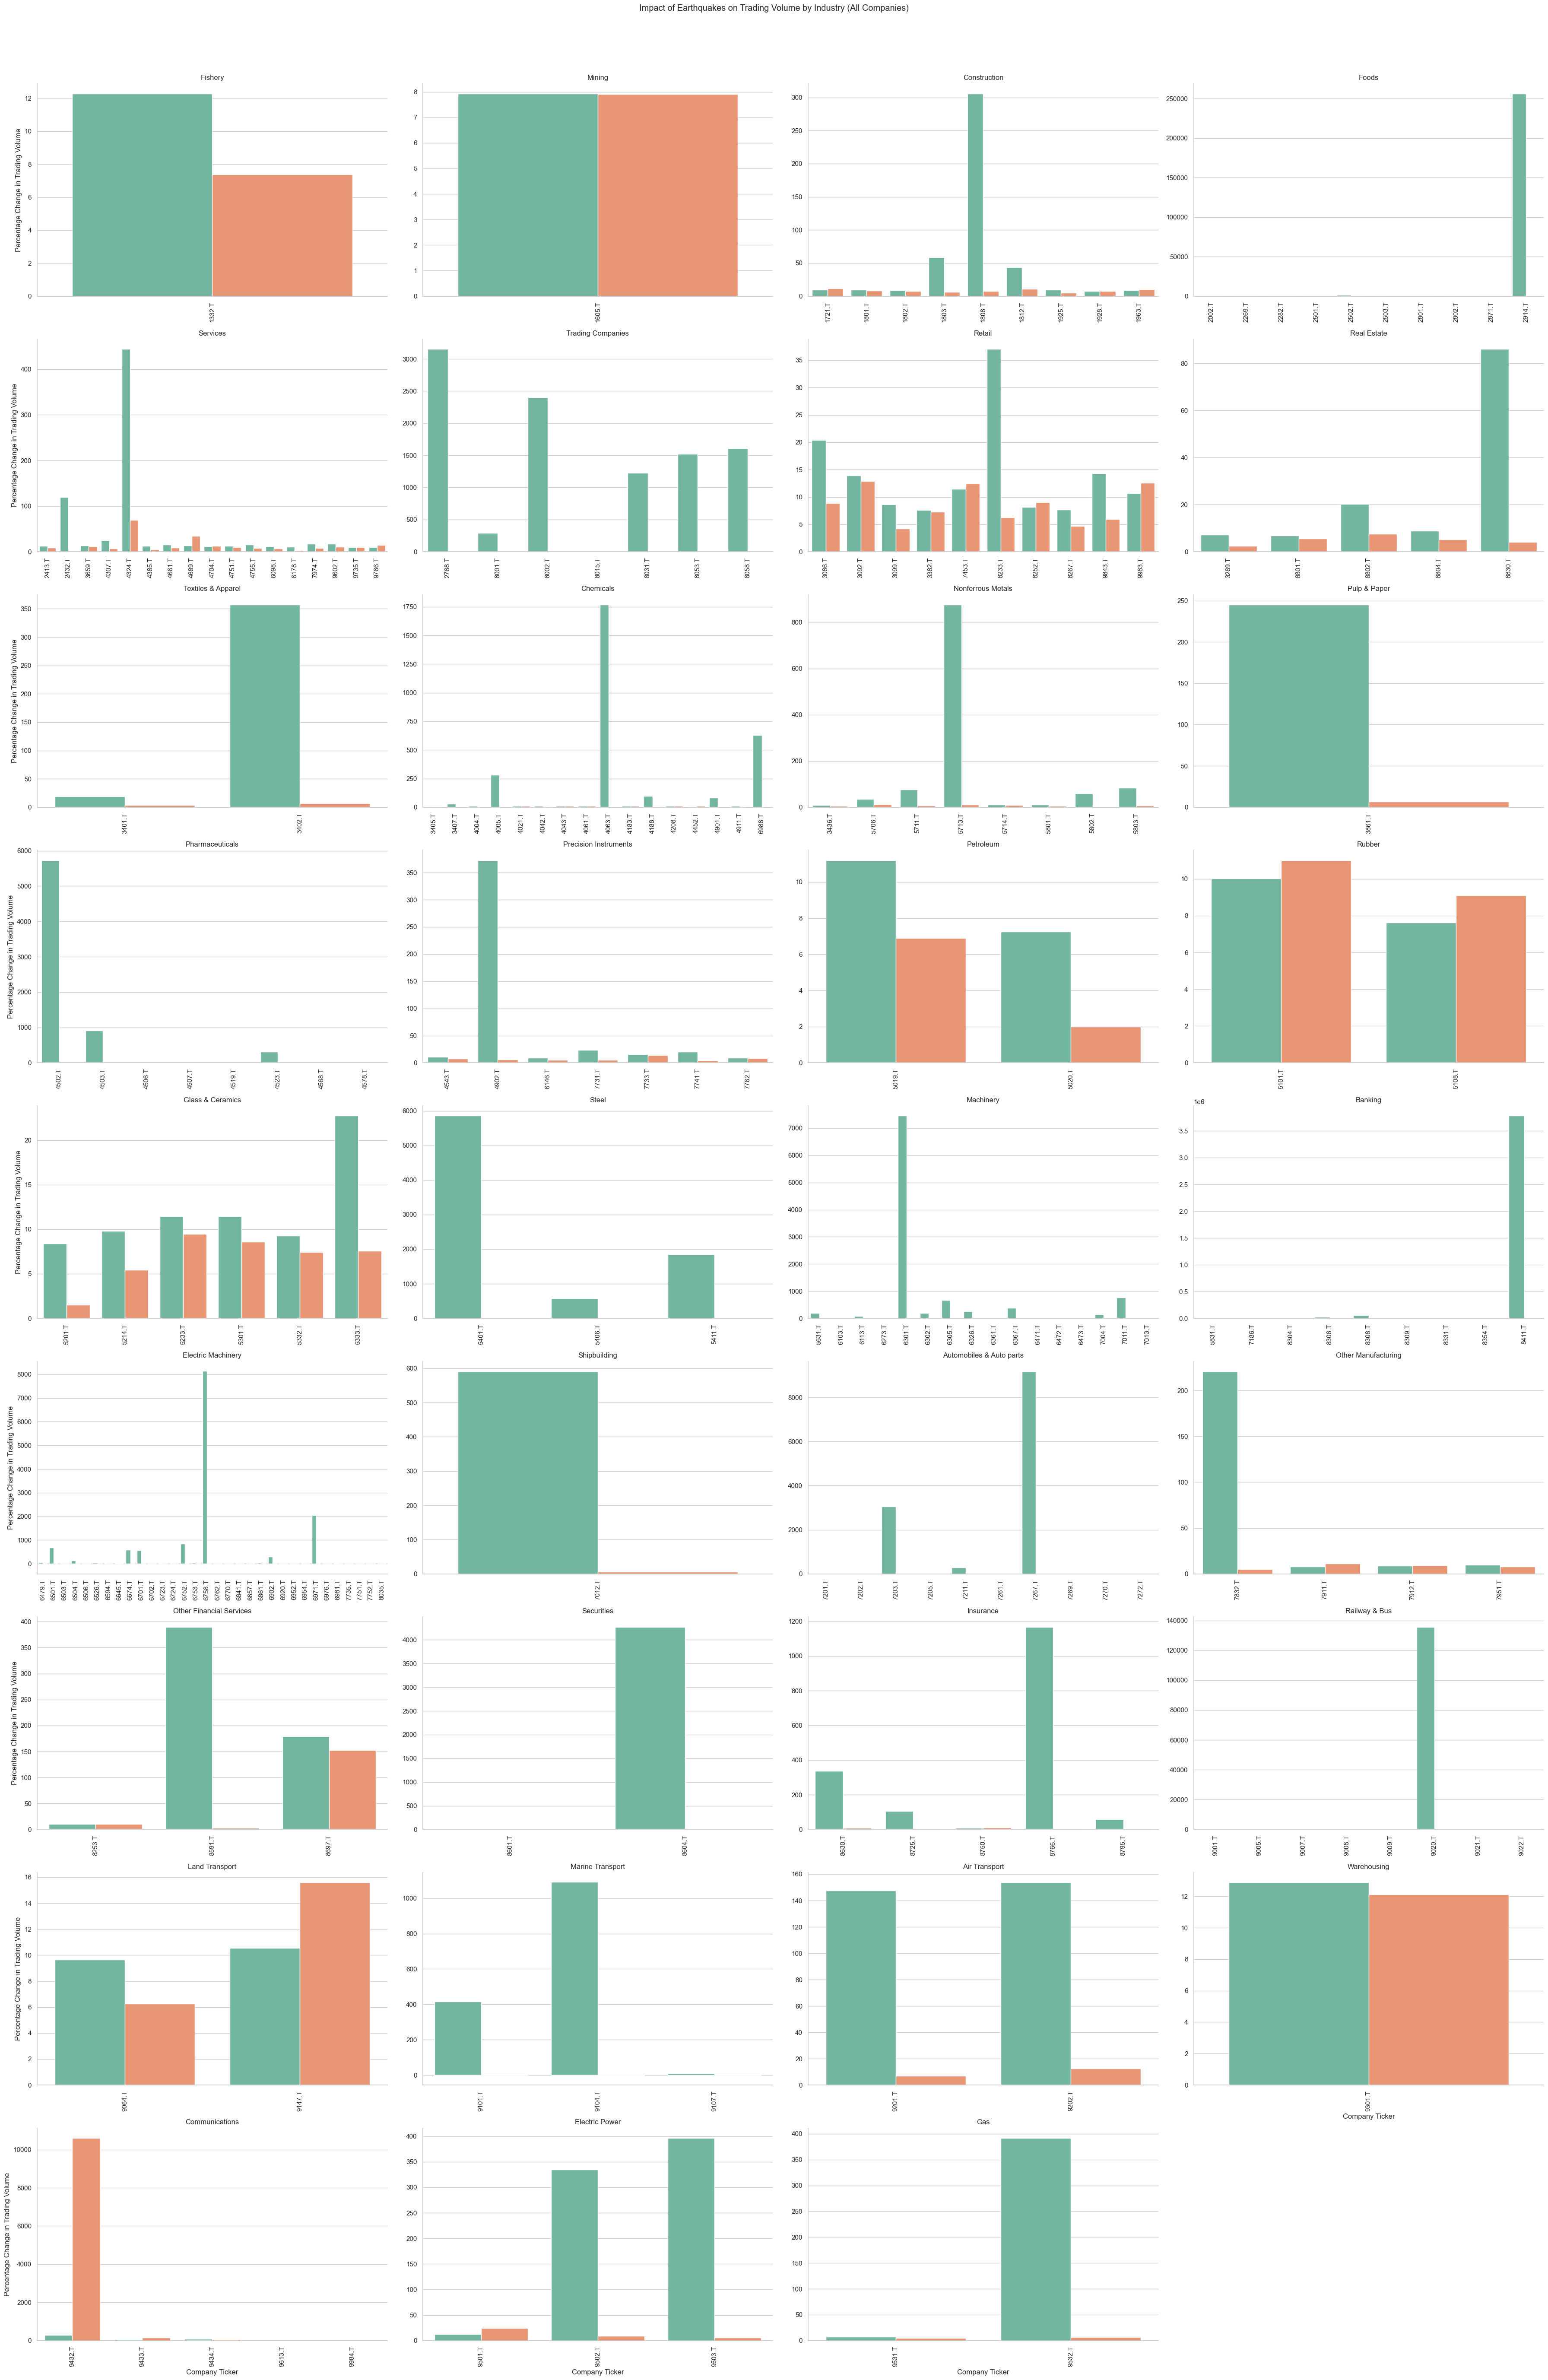

In [340]:
# Calculate the percentage change in trading volume for each company
merged_data['volume_change'] = (merged_data['Volume'] - merged_data['Volume'].shift(1)) / merged_data['Volume'].shift(1) * 100

# Replace NaN values in the first row with 0 (since there's no previous value to compare)
merged_data['volume_change'] = merged_data['volume_change'].fillna(0)

# Create a faceted bar plot for each industry, showing all companies
g = sns.FacetGrid(merged_data, col='Industry', col_wrap=4, height=6, aspect=1.5, sharey=False, sharex=False)
g.map_dataframe(sns.barplot, x='Ticker', y='volume_change', hue='earthquake', palette='Set2', dodge=True, errorbar=None)  # Fixed: Use errorbar=None instead of ci=None
g.set_axis_labels('Company Ticker', 'Percentage Change in Trading Volume')
g.set_titles('{col_name}')
g.fig.suptitle('Impact of Earthquakes on Trading Volume by Industry (All Companies)', y=1.02)

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    ax.set_xticks(ax.get_xticks())  # Fix the number of ticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# How Market performs befor and after earthquake in the range +-10 days?

C:\Users\dongv\AppData\Local\Temp\ipykernel_23812\2859359357.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalize_group)


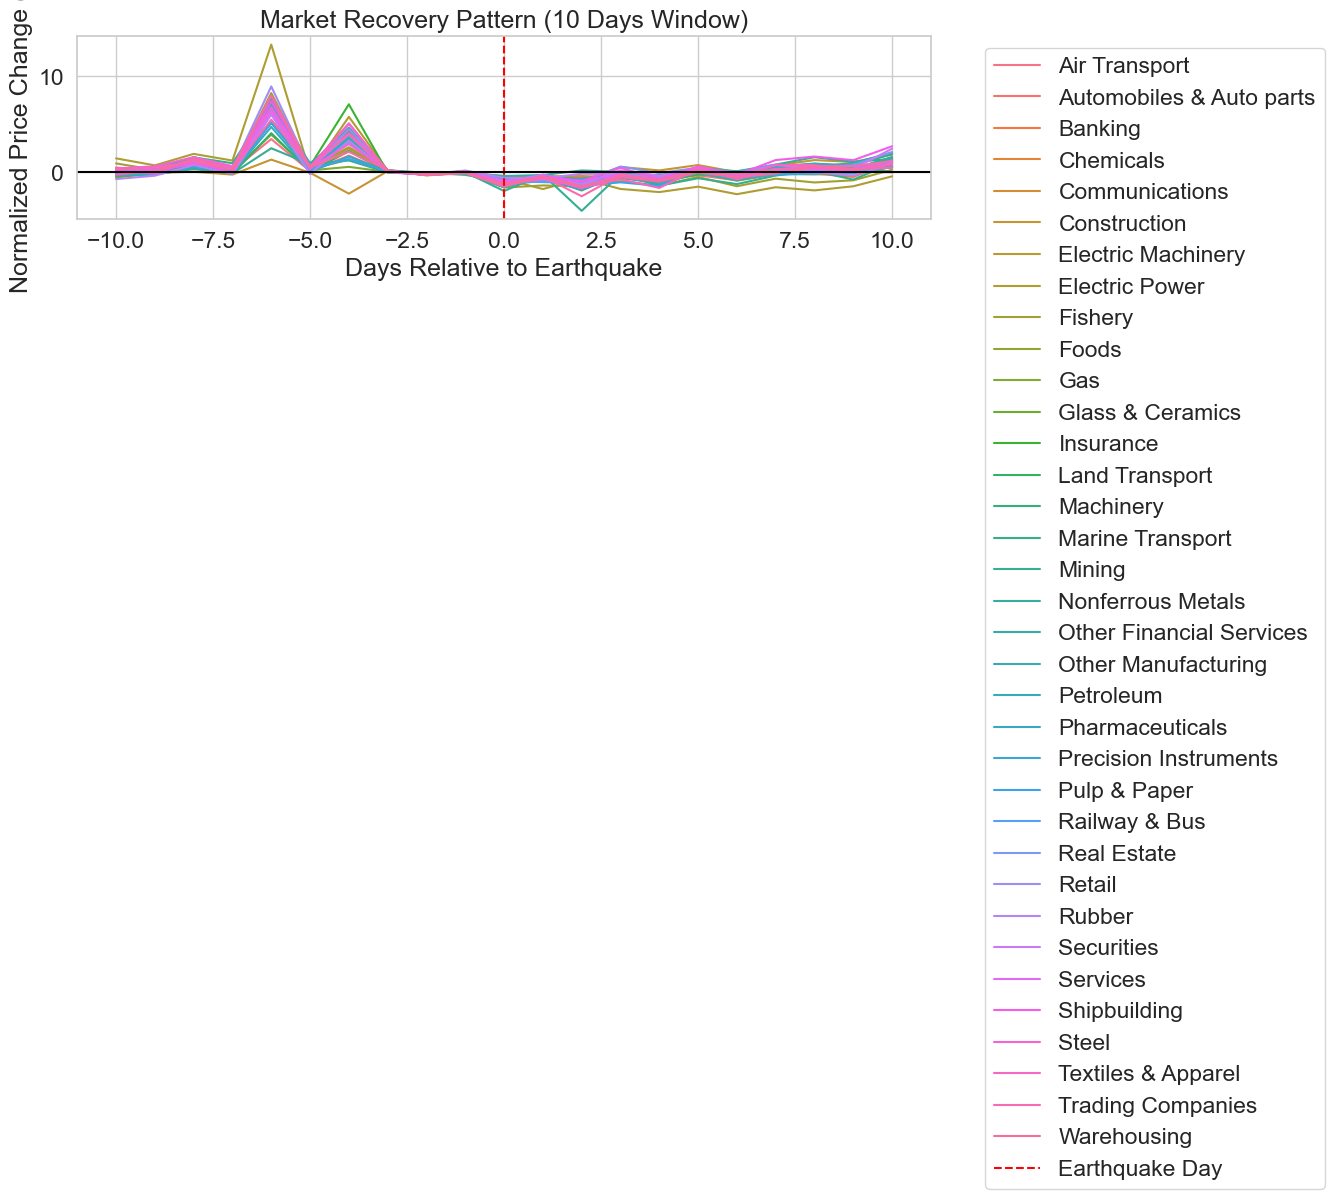


Recovery Metrics (Sorted by Maximum Impact):
                Industry  max_impact  days_to_recover  volatility
                  Mining   -4.003683                0    5.438286
       Trading Companies   -2.483982                0    4.794982
          Electric Power   -2.266551                0    8.998442
        Glass & Ceramics   -1.885504                0    5.470400
               Petroleum   -1.843547                0    5.081145
       Nonferrous Metals   -1.777865                0    5.916149
                   Steel   -1.653878                0    5.864981
               Machinery   -1.638642                0    5.765917
      Textiles & Apparel   -1.613584                0    4.718862
                 Fishery   -1.579179                0    4.970678
               Chemicals   -1.506444                0    5.107445
Automobiles & Auto parts   -1.493542                0    5.361268
      Electric Machinery   -1.483614                0    5.773487
               Insurance   -1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set parameters
WINDOW_SIZE = 10  # Days before/after earthquake to analyze
BASE_DAYS = 3     # Days before earthquake to use as baseline  # Avoids recent pre-earthquake anomalies by using a stable baseline

# Convert date columns to datetime
merged_data['Date'] = pd.to_datetime(merged_data['Date'])
earthquake_dates = merged_data[merged_data['earthquake']]['Date'].unique()  # Unique dates prevent duplicate processing of same earthquake

# Create event study dataframe
## For each earthquake, creates a [-10, +10] day window around it.
event_data = []

for eq_date in earthquake_dates:
    start_date = eq_date - pd.Timedelta(days=WINDOW_SIZE)
    end_date = eq_date + pd.Timedelta(days=WINDOW_SIZE)
    
    window_data = merged_data[
        (merged_data['Date'] >= start_date) & 
        (merged_data['Date'] <= end_date)
    ].copy()
    
    window_data['days_from_event'] = (window_data['Date'] - eq_date).dt.days   # days_from_event aligns events across different dates
    window_data['earthquake_id'] = eq_date   # earthquake_id tracks source earthquake for multi-event analysis
    event_data.append(window_data)

# Combine all event windows and reset index (prevents index conflicts from different windows)
event_study = pd.concat(event_data).reset_index(drop=True)

# Calculate normalized values
def normalize_group(group):
    group = group.reset_index()
    baseline_mask = (group['days_from_event'] >= -BASE_DAYS) & (group['days_from_event'] < 0)
    baseline = group.loc[baseline_mask, 'Close'].mean()
    
    if pd.notnull(baseline) and baseline != 0:
        group['normalized_close'] = (group['Close'] - baseline) / baseline * 100
    else:
        group['normalized_close'] = np.nan
    
    return group[['Date', 'Close', 'days_from_event', 'normalized_close',
                 'Industry', 'Ticker', 'earthquake_id']]

# Apply normalization
event_study = (
    event_study.groupby(['Industry', 'Ticker', 'earthquake_id'], group_keys=False)
              .apply(normalize_group)
              .reset_index(drop=True)
)

# Aggregate results
agg_results = event_study.groupby(['Industry', 'days_from_event'], as_index=False).agg(
    mean_change=('normalized_close', 'mean'),
    std_change=('normalized_close', 'std'),
    count=('normalized_close', 'count')
)

# Visualization
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=agg_results,
    x='days_from_event',
    y='mean_change',
    hue='Industry',
    errorbar=('ci', 95)
)
plt.axvline(0, color='red', linestyle='--', label='Earthquake Day')
plt.axhline(0, color='black', linestyle='-')
plt.title(f'Market Recovery Pattern ({WINDOW_SIZE} Days Window)')
plt.xlabel('Days Relative to Earthquake')
plt.ylabel('Normalized Price Change (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate and sort recovery metrics
recovery_analysis = (
    agg_results[agg_results['days_from_event'] >= 0]
    .groupby('Industry')
    .agg(
        max_impact=('mean_change', lambda x: x.min() if x.min() < 0 else x.max()),
        days_to_recover=('mean_change', lambda x: np.argmax(x <= 0) if any(x <= 0) else np.nan),
        volatility=('std_change', 'mean')
    )
    .reset_index()
    .sort_values('max_impact', ascending=True)  # Sort by most negative impact first
)

print("\nRecovery Metrics (Sorted by Maximum Impact):")
print(recovery_analysis.to_string(index=False))

# In above result, days_to_recover = 0 for every industries, that is strange. The code will need to be reconsidered. 

In [ ]:
# Add a column to indicate if an earthquake occurred on a given date
merged_data['earthquake_occurred'] = merged_data['date'].notna()

# Calculate the percentage change in stock prices for each company
merged_data['price_change'] = merged_data.groupby('Company_name')['Close'].pct_change()

# Filter data for the period 2008-2023
# Convert the date strings to datetime64[ns] for comparison
start_date = pd.to_datetime('2008-01-01')
end_date = pd.to_datetime('2023-12-31')

merged_data = merged_data[
    (merged_data['Date'] >= start_date) & 
    (merged_data['Date'] <= end_date)
]

# Group by industry and company to analyze the impact of earthquakes
industry_company_impact = merged_data.groupby(
    ['Industry', 'Company_name', 'earthquake_occurred']
)['price_change'].mean().reset_index()

# Pivot the data for better visualization
pivot_data = industry_company_impact.pivot_table(
    index=['Industry', 'Company_name'], 
    columns='earthquake_occurred', 
    values='price_change'
).reset_index()

# Rename columns for clarity
pivot_data.columns = ['Industry', 'Company_name', 'No_Earthquake', 'Earthquake']

# Calculate the difference in impact
pivot_data['Impact_Difference'] = pivot_data['Earthquake'] - pivot_data['No_Earthquake']

# Display the pivoted data
print(pivot_data.head())

                   Industry              Company_name  No_Earthquake  \
0             Air Transport         ANA HOLDINGS INC.       0.000185   
1             Air Transport  JAPAN AIRLINES CO., LTD.       0.498600   
2  Automobiles & Auto parts         HINO MOTORS, LTD.       0.000435   
3  Automobiles & Auto parts     HONDA MOTOR CO., LTD.       0.000449   
4  Automobiles & Auto parts         ISUZU MOTORS LTD.       0.000778   

   Earthquake  Impact_Difference  
0   -0.001906          -0.002091  
1   -0.000571          -0.499171  
2   -0.003371          -0.003806  
3   -0.001447          -0.001896  
4   -0.004082          -0.004860  
